In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
from ModelTraining.DataLoaderTrans import MotionDataset,motion_collate_fn

In [2]:
import pandas as pd
import numpy as np

In [3]:
# === Configuration ===
PT_FOLDER = "/Users/mrinalraj/Downloads/WebDownload/Driving48/videosTensors1000"
CSV_PATH = "/Users/mrinalraj/Downloads/WebDownload/Driving48/df_exsists.csv"
SAVE_VIDEO = False  # Set to True to save as .mp4

# === Load CSV and Dataset ===
df = pd.read_csv(CSV_PATH)
dataset = MotionDataset(df, PT_FOLDER, training=False)

# === Load One Sample ===
input_tensor, label, vid_name = dataset[0]  # [T, N, 5]
print(f"Loaded video: {vid_name}, Label: {label}, Shape: {input_tensor.shape}")


Loaded video: 3qq031609lA_00002, Label: 0, Shape: torch.Size([124, 1000, 5])


In [7]:
positions = input_tensor[..., 0:2]  # [T, N, 2]
velocity = input_tensor[..., 3:5]   # [T, N, 2]
T, N, _ = velocity.shape

In [9]:
positions.shape, velocity.shape, T, N, _

(torch.Size([124, 1000, 2]), torch.Size([124, 1000, 2]), 124, 1000, 2)

In [10]:
velocity

tensor([[[ 0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00]],

        [[-1.0552e-03,  1.0555e-02],
         [ 2.1160e-05,  3.2515e-03],
         [ 9.6476e-04,  8.0588e-03],
         ...,
         [ 1.0547e-04,  5.7399e-04],
         [ 2.8348e-04,  9.3355e-03],
         [ 2.0653e-04,  8.9690e-04]],

        [[-7.7516e-04,  1.6158e-02],
         [ 4.4525e-05,  1.2340e-02],
         [ 6.2609e-04,  1.6189e-02],
         ...,
         [ 7.2539e-05, -3.6317e-04],
         [ 4.5061e-05,  1.6353e-02],
         [ 2.6938e-04, -4.0948e-04]],

        ...,

        [[ 3.5525e-03,  5.2508e-03],
         [-7.8669e-04, -1.5638e-03],
         [ 2.5347e-04, -4.8995e-04],
         ...,
         [ 4.1178e-03,  1.5141e-02],
         [ 8.8039e-04, -1.5475e-03],
         [ 1.3911e-03,  1.2846e-02]],

        [[-7.7217e-03, -7.3044e-03

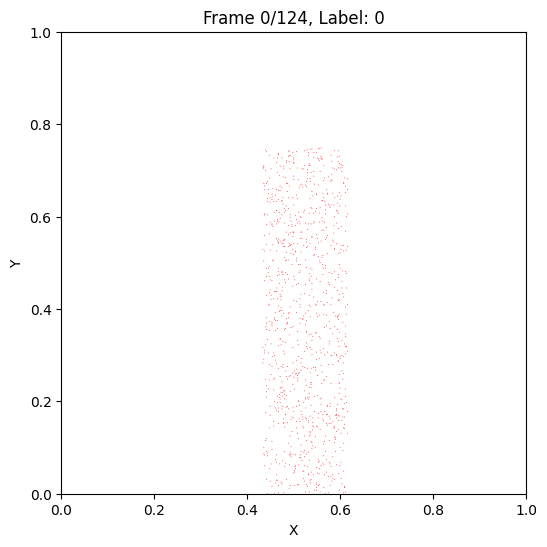

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
quiver = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color='blue')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"Velocity Visualization - {vid_name}")

def update(frame):
    ax.clear()
    pos = positions[frame]
    vel = velocity[frame]
    ax.quiver(
        pos[:, 0], pos[:, 1], vel[:, 0], vel[:, 1],
        angles='xy', scale_units='xy', scale=1, color='red', width=0.002
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"Frame {frame}/{T}, Label: {label}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    return ax,

# === Animate ===
ani = animation.FuncAnimation(fig, update, frames=T, interval=100, blit=False)

In [12]:
output_path = f"{vid_name}_velocity.mp4"
ani.save(output_path, fps=10)
print(f"Saved velocity video to {output_path}")


Saved velocity video to 3qq031609lA_00002_velocity.mp4
